In [1]:
from itertools import product
import pickle
import json
import h5py
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from popsummary.popresult import PopulationResult
from astropy.cosmology import Planck15
from astropy import units as u


plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14
plt.rcParams["text.usetex"] = True

In [2]:
def q_flat(x):
    ans=1/(5-(-15))

    return ans


def kl_divergence_kde_p_known_q(p_samples, q_pdf, base=np.e, bandwidth='scott'):
    """
    Estimate KL divergence D_KL(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated KL divergence D_KL(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde = gaussian_kde(p_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde(p_samples)
    q_vals = q_pdf(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_vals = np.clip(q_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_vals)
    kl = np.mean(log_ratio)

    return kl / np.log(base)


def kl_divergence_kde(p_samples, q_samples, base=np.e, bandwidth='scott'):
    """
    Estimate delta divergence D_delta(P || Q) where:
      - P is known via samples (estimated with KDE)
      - Q is known via samples (estimated with KDE)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_samples (array): 1D array of samples from Q
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated delta divergence D_delta(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde_p = gaussian_kde(p_samples, bw_method=bandwidth)

    q_samples = np.asarray(q_samples)
    kde_q = gaussian_kde(q_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde_p(p_samples)
    q_kde_vals = kde_q(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_kde_vals = np.clip(q_kde_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_kde_vals)
    delta = np.mean(log_ratio)

    return delta / np.log(base)

In [3]:
def power_law_peak(m1, gaussian_params, powlaw_params, smooth_params):
    gauss_pdf = stats.norm(
            loc=gaussian_params[1], scale=gaussian_params[2]
        ).pdf(m1)

    indx, lower, upper = powlaw_params
    out_bounds = np.logical_or(m1 < lower, m1 > upper)
    norm = (upper**(1 - indx) - lower**(1 - indx)) / (1 - indx)

    powlaw_pdf = m1**(-indx) / norm

    weight = gaussian_params[0]
    result = weight * gauss_pdf + (1 - weight) * powlaw_pdf

    sig = smooth_params[0]
    smooth = np.zeros_like(m1)
    in_smooth = np.logical_or(m1 >= lower, m1 < lower+sig)
    f = lambda m: np.exp(sig/m + sig/(m-sig))
    smooth[in_smooth] = 1 /(f(m1-lower)+1)
    smooth[m1>=lower+sig]=1

    return np.where(out_bounds, 0, result*smooth)

def massratio_pdf(q, m1, beta_q, lower, upper, smooth_params):
    out_bounds = np.logical_or(m1 < lower, m1 > upper)
    norm = (upper**(1 + beta_q) - lower**(1 + beta_q)) / (1 + beta_q)

    powlaw_pdf = q**beta_q /norm

    sig = smooth_params[0]
    smooth = np.zeros((len(m1),len(q)))
    in_smooth = np.logical_and(m1 >= lower, m1 < lower+sig)
    f = lambda m: np.exp(sig/m + sig/(m-sig))
    smooth[in_smooth] = 1 /(f(q * m1[in_smooth,None]-lower)+1)
    smooth[m1>=lower+sig]=1

    return powlaw_pdf * smooth

def q_prior(q, m1, beta_q, m_min):
    out_bounds = q * m1 < m_min
    normalisation = (beta_q + 1) / (1 - (m_min / m1) ** (beta_q + 1))
    p_of_q = normalisation * q**beta_q
    return np.where(out_bounds, 0, p_of_q)

def simple_massratio_pdf(q, beta_q):
    norm = (1 + beta_q) /(1 - 0.1**(1+beta_q))
    return q**beta_q *norm

## Use LVK population analysis results as `true' population

In [4]:
gwtc3 = '/home/tristan-bruel/Documents/Science/LVK/gwtc3'
zeval = 0.
color_plpeak = "#1f78b4"

O3_only_PPD = os.path.join(gwtc3,'analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_mass_data.h5')

mass_1_gwtc3 = np.linspace(2, 100, 1000)
mass_ratio_gwtc3 = np.linspace(0.1, 1, 500)
with h5py.File(O3_only_PPD, "r") as f:
    mass_ppd = f["ppd"]
    mass_lines = f["lines"]
    mass_1_ppd = np.trapezoid(y=mass_ppd, x=mass_ratio_gwtc3, axis=0)
    mass_r_ppd = np.trapezoid(y=mass_ppd, x=mass_1_gwtc3, axis=-1)
    mass_1_lower = np.percentile(mass_lines["mass_1"], 5, axis=0)
    mass_1_upper = np.percentile(mass_lines["mass_1"], 95, axis=0)
    mass_r_lower = np.percentile(mass_lines["mass_ratio"], 5, axis=0)
    mass_r_upper = np.percentile(mass_lines["mass_ratio"], 95, axis=0)

In [5]:
tf = os.path.join(gwtc3,"analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_result.json")
with open(tf) as jf:
    data = json.load(jf)['posterior']['content']
kappas_gwtc3 = np.array(data['lamb'])
R0_gwtc3 = np.array(data['rate'])
## Primary mass gaussian peak ##
lambdas = np.array(data['lam'])
mu_m = np.array(data['mpp'])
sigma_m = np.array(data['sigpp'])
gaussian_params = np.vstack([lambdas, mu_m, sigma_m]).T
## Primary mass power-law dist ##
alphas = np.array(data['alpha'])
mmin = np.array(data['mmin'])
mmax = np.array(data['mmax'])
powlaw_params = np.vstack([alphas, mmin, mmax]).T
## Smoothing parameter ##
delta_m = np.array(data['delta_m'])
smooth_params = np.vstack([delta_m]).T
## Mass ratio power-law index ##
betas = np.array(data['beta'])

# Downselect to a reasonable number of hyperparameter samples
num_pop_LVK = 100
inds = np.random.choice(np.arange(R0_gwtc3.size), size=num_pop_LVK, replace=False)

# Define a grid of redshifts, and prepare corresponding arrays to hold R(z)
zs_gwtc3 = np.linspace(0,1.5,100)
Rz_gwtc3 = np.zeros((inds.size,zs_gwtc3.size))
dRdm1_gwtc3 = np.zeros((inds.size,mass_1_gwtc3.size))
dRdq_gwtc3 = np.zeros((inds.size,mass_ratio_gwtc3.size))
# For each of our randomly selected samples, compute and save R(z)
for i,ind in enumerate(inds):
    Rz_gwtc3[i,:] = R0_gwtc3[ind]*(1.+zs_gwtc3)**kappas_gwtc3[ind]
    Rnorm = R0_gwtc3[ind]
    m1_pdf = power_law_peak(mass_1_gwtc3, gaussian_params[ind], powlaw_params[ind], smooth_params[ind])
    norm = np.trapezoid(x=mass_1_gwtc3, y=m1_pdf)
    dRdm1_gwtc3[i,:] = Rnorm * m1_pdf /norm
    # q_pdf_m1 = massratio_pdf(mass_ratio_gwtc3, mass_1_gwtc3, betas[ind], 
    #                          powlaw_params[ind][1], powlaw_params[ind][2],
    #                          smooth_params[ind])
    # q_pdf = np.array(
    #     [np.trapezoid(x=mass_1_gwtc3, y=q_pdf_m1[:,i]*m1_pdf)
    #         for i in range(len(mass_ratio_gwtc3))
    #     ])
    # norm = np.trapezoid(x=mass_ratio_gwtc3, y=q_pdf)
    # dRdq_gwtc3[i,:] = Rnorm * q_pdf /norm
    q_pdf = simple_massratio_pdf(mass_ratio_gwtc3, betas[ind])
    dRdq_gwtc3[i,:] = Rnorm * q_pdf

/tmp/ipykernel_7207/3197589498.py:18: RuntimeWarning: overflow encountered in exp
  f = lambda m: np.exp(sig/m + sig/(m-sig))


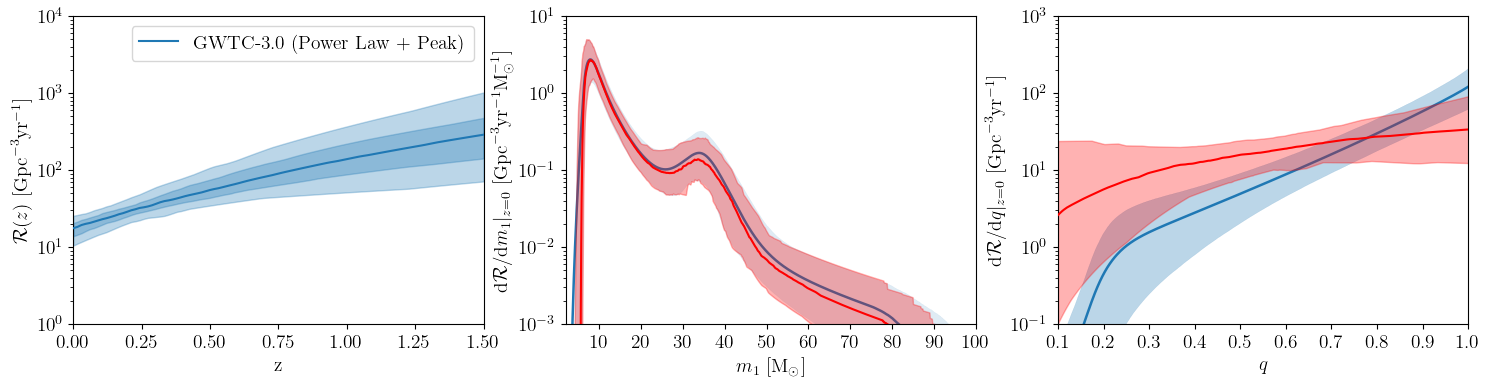

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))

# Merger rate with redshift #
ax = axes[0]
ax.plot(zs_gwtc3, np.median(Rz_gwtc3,axis=0),
        color=color_plpeak, lw=1.5, zorder=5,
        label='GWTC-3.0 (Power Law + Peak)',
       )
ax.fill_between(zs_gwtc3,
        np.quantile(Rz_gwtc3,0.05,axis=0),
        np.quantile(Rz_gwtc3, 0.95, axis=0),
        color=color_plpeak, alpha=0.3)
ax.fill_between(zs_gwtc3,
        np.quantile(Rz_gwtc3,0.25,axis=0),
        np.quantile(Rz_gwtc3, 0.75, axis=0),
        color=color_plpeak, alpha=0.3)

ax.set_xlabel('z')
ax.set_xlim(xmin=0, xmax=1.5)
ax.set_ylabel(r'$\mathcal{R}(z)\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1, ymax=1e4)
ax.legend()

# Primary mass #
ax = axes[1]
ax.plot(mass_1_gwtc3, mass_1_ppd,
        color=color_plpeak, lw=1.8, zorder=1)
ax.fill_between(mass_1_gwtc3,
        mass_1_lower,
        mass_1_upper,
        color=color_plpeak, lw=0.2, alpha=0.14, zorder=0)
ax.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
ax.set_xlim(xmin=2., xmax=100.)
ax.set_xticks(np.linspace(10,100,10))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=0}\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_\odot^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1e-3, ymax=10)
ax.plot(mass_1_gwtc3, np.median(dRdm1_gwtc3,axis=0),
        color='r', lw=1.5, zorder=5,
       )
ax.fill_between(mass_1_gwtc3,
        np.quantile(dRdm1_gwtc3,0.05,axis=0),
        np.quantile(dRdm1_gwtc3, 0.95, axis=0),
        color='r', alpha=0.3)

# Mass ratio #
ax = axes[2]
ax.plot(mass_ratio_gwtc3, mass_r_ppd,
        color=color_plpeak, lw=1.8, zorder=1)
ax.fill_between(mass_ratio_gwtc3,
        mass_r_lower,
        mass_r_upper,
        color=color_plpeak, lw=0.2, alpha=0.3, zorder=0)
ax.set_xlabel(r'$q$')
ax.set_xlim(xmin=0.1, xmax=1)
ax.set_xticks(np.linspace(0.1,1,10))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=0}\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=0.1, ymax=1e3)
ax.plot(mass_ratio_gwtc3, np.median(dRdq_gwtc3,axis=0),
        color='r', lw=1.5, zorder=5,
       )
ax.fill_between(mass_ratio_gwtc3,
        np.quantile(dRdq_gwtc3,0.05,axis=0),
        np.quantile(dRdq_gwtc3, 0.95, axis=0),
        color='r', alpha=0.3)

plt.show()
plt.close()

In [7]:
print('R(z=%.2f), integral dR/dm1, integral dR/dq' %zeval)
for ind in range(3):
    Rzeval = interp1d(zs_gwtc3, Rz_gwtc3[ind,:])(zeval)
    int_dRdm1 = np.trapezoid(x=mass_1_gwtc3, y=dRdm1_gwtc3[ind])
    int_dRdq = np.trapezoid(x=mass_ratio_gwtc3, y=dRdq_gwtc3[ind])
    print(Rzeval, int_dRdm1, int_dRdq)

R(z=0.00), integral dR/dm1, integral dR/dq
18.687455547798088 18.687455547798088 18.687471873309814
17.711126309361298 17.7111263093613 17.71120997166603
23.112426197430043 23.112426197430043 23.112420501352062


## GW events

In [8]:
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "tilt1", "tilt2"]

data_file = np.load("./lvc_data_lvc_samples_full.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
num_events = data_file["nevents"][0]
num_samples = data_file["nsamples"][0]
event_priors = data_file["priors"]
print(
        f"Running with {num_events} events × {num_samples} samples = {num_events*num_samples} total samples"
    )

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

Running with 69 events × 4278 samples = 295182 total samples


## Triangulation setup

In [9]:
z_min = 1e-6
z_max = 1.5
m1_min = 3.0
m1_max = 100.0 + 1e-6
q_min = 0.
q_max = 1.

w_min = -20
w_max = 15
nvertices_min = 4
nvertices_max = 100

corners = np.array([ 
        [m1_min, z_min, q_min],
        [m1_min, z_min, q_max],
        [m1_min, z_max, q_min],
        [m1_min, z_max, q_max],
        [m1_max, z_min, q_min],
        [m1_max, z_min, q_max],
        [m1_max, z_max, q_min], 
        [m1_max, z_max, q_max],
    ])

print(corners)

[[3.00000000e+00 1.00000000e-06 0.00000000e+00]
 [3.00000000e+00 1.00000000e-06 1.00000000e+00]
 [3.00000000e+00 1.50000000e+00 0.00000000e+00]
 [3.00000000e+00 1.50000000e+00 1.00000000e+00]
 [1.00000001e+02 1.00000000e-06 0.00000000e+00]
 [1.00000001e+02 1.00000000e-06 1.00000000e+00]
 [1.00000001e+02 1.50000000e+00 0.00000000e+00]
 [1.00000001e+02 1.50000000e+00 1.00000000e+00]]


## Some diagnostics of the sampling

In [10]:
backend_file = 'outdir0/backend'
with open(backend_file, "rb") as f:
    back = pickle.load(f)
ntemps = back.ntemps
nwalkers = back.nwalkers
nsteps = back.chain['tri'].shape[0]
tri_sizes = np.array([
        back.inds["tri"][step, 0, walker].sum()
        for step, walker in product(range(nsteps), range(nwalkers))
        ])

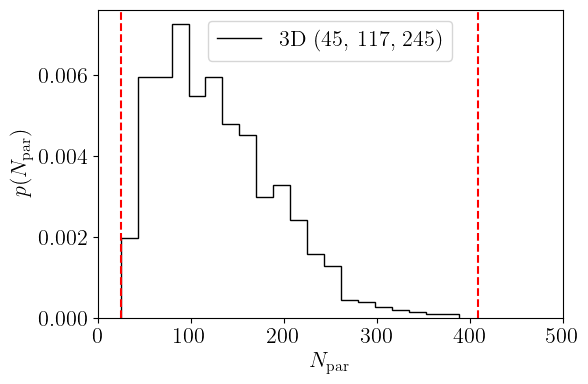

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
ax.set(
    yscale="linear",
    xlabel=r"$N_{\mathrm{par}}$",
    ylabel=r"$p(N_{\mathrm{par}})$",
    xlim=(0, 500),
)

ls = ["-", "--", ":"]

ind=0
ndim=3
offset=2**ndim

n_params = tri_sizes * (ndim + 1) + offset + 1

l, m, h = np.quantile(n_params, [0.05, 0.5, 0.95]).astype(int)

hist, edges = np.histogram(n_params, density=True, bins=20)
ax.stairs(
    hist,
    edges, 
    color='black', 
    ls=ls[ind], 
    label=f"{ndim}D ({l}, {m}, {h})"
)

ax.axvline(nvertices_min * (ndim + 1) + offset + 1, color='r', linestyle='--')
ax.axvline(nvertices_max * (ndim + 1) + offset + 1, color='r', linestyle='--')

ax.legend()
plt.show()
plt.close()

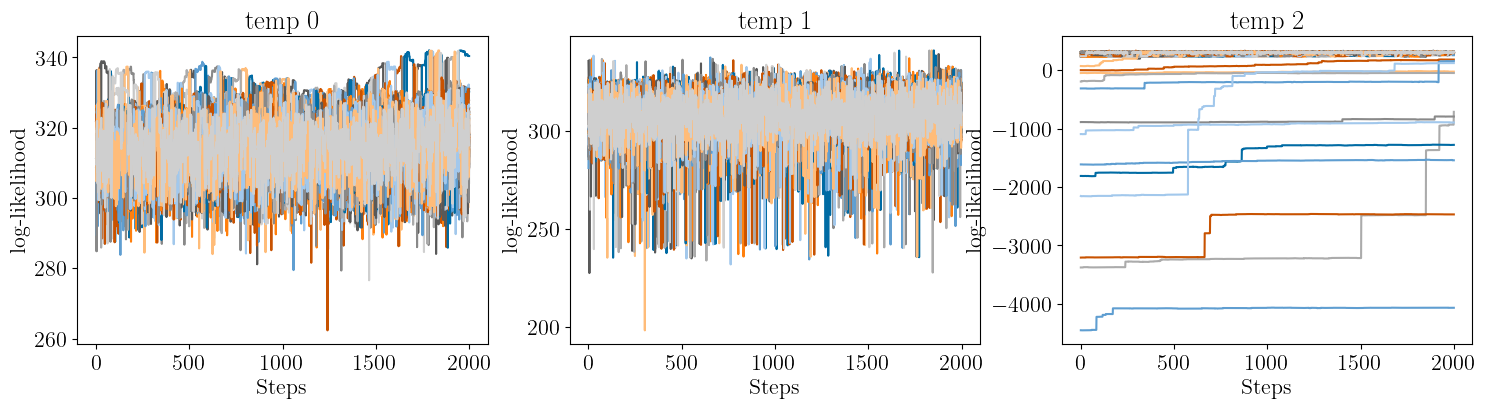

In [12]:
fig, axes = plt.subplots(1, ntemps, figsize=(18,4))
for t,w in product(range(ntemps),range(nwalkers)):
    ax = axes[t]
    ax.plot(back.get_log_like()[:, t, w])
    ax.set(title=f"temp {t}")
    ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-likelihood")
plt.show()
plt.close()

In [13]:
nburn = 1_000

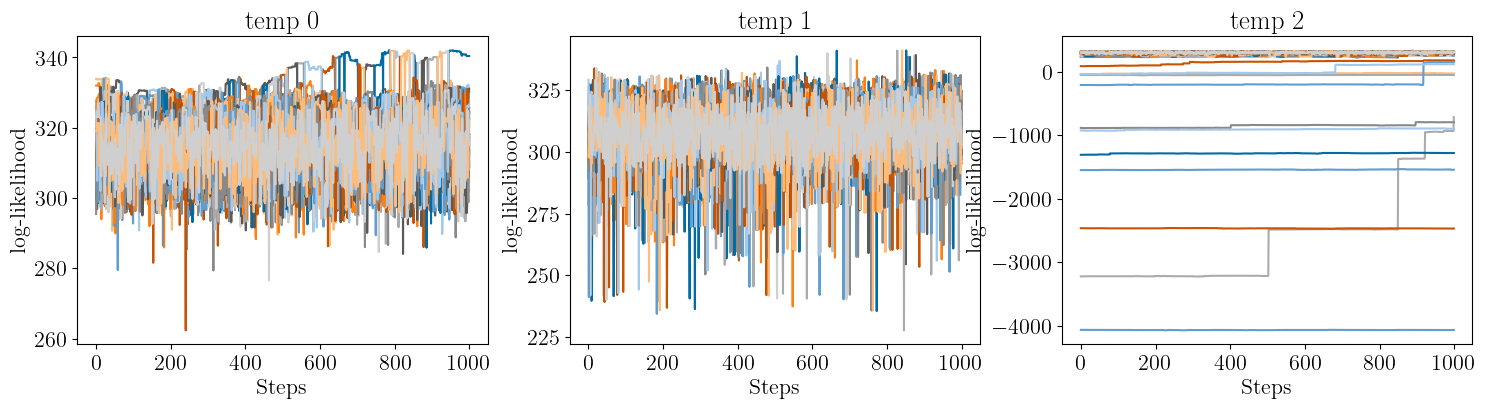

In [14]:
fig, axes = plt.subplots(1, ntemps, figsize=(18,4))
for t,w in product(range(ntemps),range(nwalkers)):
    ax = axes[t]
    ax.plot(back.get_log_like()[nburn:, t, w])
    ax.set(title=f"temp {t}")
    ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-likelihood")
plt.show()
plt.close()

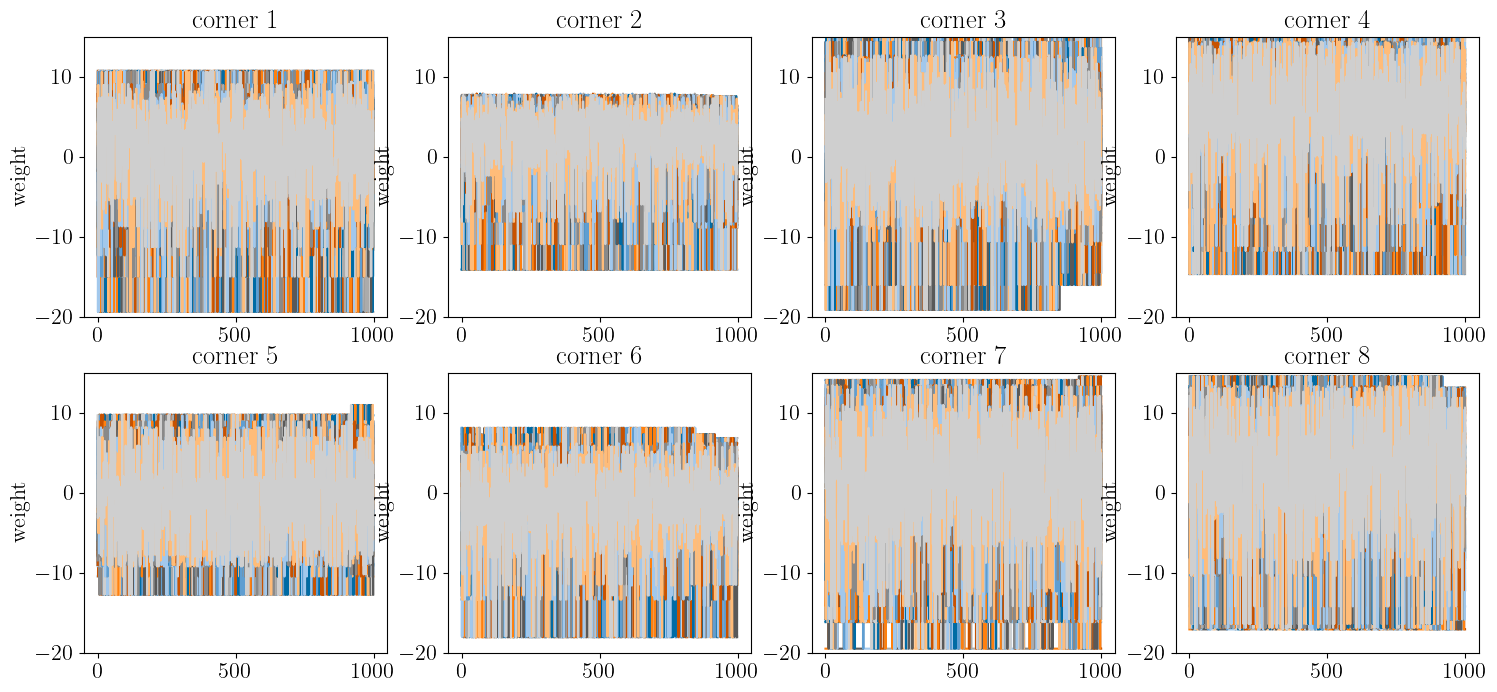

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
for n in range(len(corners)):
    ax = axes[n//4, n%4]
    for t,w in product(range(ntemps-1),range(nwalkers)):
        ax.plot(np.ravel(back.chain['corner_w'][nburn:,t,w,0,n]))
    # t=0
    # for w in range(nwalkers):
    #     ax.plot(np.ravel(back.chain['corner_w'][nburn:,t,w,0,n]))
    ax.set(title=f"corner {n+1}")
    #ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"weight")
    ax.set_ylim(w_min,w_max)
plt.show()
plt.close()

## Load triangulations

In [16]:
all_triangulations = []
for t in range(ntemps-1):
    triangulations = [
        back.chain["tri"][step, t, walker][back.inds["tri"][step, t, walker]]
        for step, walker in product(range(nburn,nsteps), range(nwalkers))
    ]
    corner_weights = np.array(
        [
            back.chain["corner_w"][step, t, walker]
            for step, walker in product(range(nburn,nsteps), range(nwalkers))
        ]
    )
    for ind in tqdm(range(len(triangulations))):
        all_triangulations.extend([
            np.vstack([triangulations[ind], np.c_[corners, corner_weights[ind].T]])                
        ])
### KEEP ONLY FIRST TEMPERATURE FOR NOW ###
# t=0
# triangulations = [
#     back.chain["tri"][step, t, walker][back.inds["tri"][step, t, walker]]
#     for step, walker in product(range(nburn,nsteps), range(nwalkers))
# ]
# corner_weights = np.array(
#     [
#         back.chain["corner_w"][step, t, walker]
#         for step, walker in product(range(nburn,nsteps), range(nwalkers))
#     ]
# )
# for ind in tqdm(range(len(triangulations))):
#     all_triangulations.extend([
#         np.vstack([triangulations[ind], np.c_[corners, corner_weights[ind].T]])                
#     ])

100%|████████████████████████████████| 40000/40000 [00:00<00:00, 216146.92it/s]


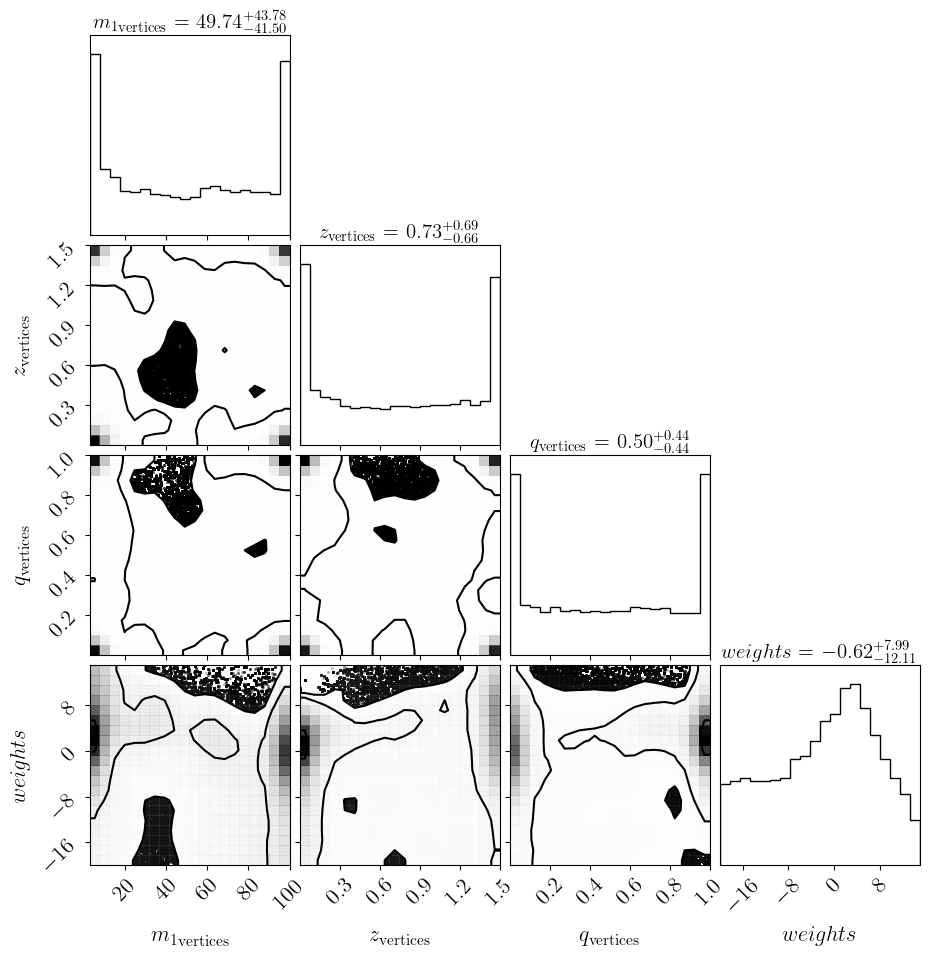

In [17]:
ws = np.hstack([tri[:, -1] for tri in all_triangulations])
vertices = np.vstack([tri[:, :-1] for tri in all_triangulations])    
corner_plot(np.c_[vertices, ws], smooth=True, levels=[0.05, 0.5, 0.95],
            labels=[r"${m_1}_\mathrm{vertices}$", r"$z_\mathrm{vertices}$", r"$q_\mathrm{vertices}$", r"$weights$"],
            show_titles=True,
            title_kwargs={"fontsize": 15},
           )
plt.show()
plt.close()

In [18]:
## Evolution of the inferred rate at a fixed point ##
targets = np.array([[10.,0.2,0.8],[35.,0.2,0.8],[35.,1.0,0.8],[35.,0.2,0.5]])
selected_tris = np.random.choice(len(all_triangulations), size=1000, replace=False)
num_triangulations = len(selected_tris)

log_rate_at_target = np.zeros((num_triangulations,4))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_at_target[ind] = this_delo.interpolate(targets)

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 1189.09it/s]


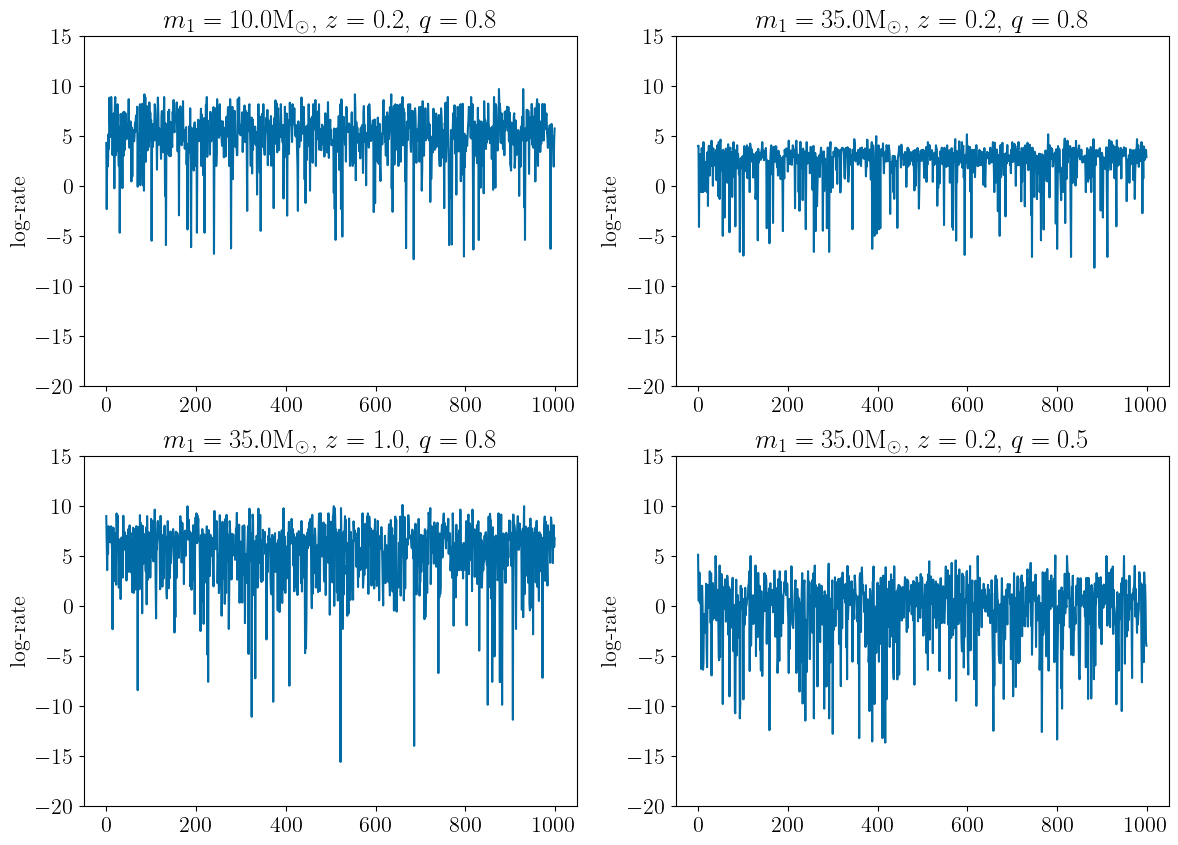

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for n in range(len(targets)):
    ax = axes[n//2, n%2]
    ax.plot(log_rate_at_target[:,n])
    ax.set(title=r"$m_1=%.1f\mathrm{M}_\odot$, $z=%.1f$, $q=%.1f$" 
           %(targets[n][0],targets[n][1],targets[n][2]))
    #ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-rate")
    ax.set_ylim(w_min,w_max)
plt.show()
plt.close()

## Compute rate over grids

In [20]:
Tobs = 66997600.0 /(24 * 3600 * 365.25) # in years

In [21]:
m1_grid = np.linspace(m1_min, m1_max, 49)
z_grid = np.linspace(0.1, z_max, 50)
q_grid = np.linspace(q_min, q_max, 51)

X, Y, Z = np.meshgrid(m1_grid, z_grid, q_grid)
grid = np.c_[X.ravel(), Y.ravel(), Z.ravel()]

dm1 = m1_grid[1] - m1_grid[0]
dz = z_grid[1] - z_grid[0]
dq = q_grid[1] - q_grid[0]

to_comoving_volume = (1 + z_grid) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value
    )

In [22]:
# selected_tris = range(0, len(all_triangulations), 40)
selected_tris = np.random.choice(len(all_triangulations), size=1000, replace=False)
num_triangulations = len(selected_tris)

log_rate = np.zeros((num_triangulations, grid.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate[ind] = this_delo.interpolate(grid)
    
square_rate = log_rate.reshape(num_triangulations, z_grid.shape[0], m1_grid.shape[0], q_grid.shape[0])

100%|██████████████████████████████████████| 1000/1000 [00:17<00:00, 56.06it/s]


In [23]:
median = np.quantile(square_rate, 0.5, axis=0)
low = np.quantile(square_rate, 0.05, axis=0)
high = np.quantile(square_rate, 0.95, axis=0)

### Injections

In [24]:
injections_file = np.load("./selection_function_elements.npz")
detected_injections = np.vstack(
    [injections_file[key + "s"] for key in parameter_keys]
).T
injection_priors = injections_file["inj_priors"]
num_injections = injections_file["ninjs"]

## Prior

In [25]:
nsamples_prior = 1_000
log_rate_prior = np.zeros((nsamples_prior, grid.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+offset,ndim+1))
    tri_i[:offset,:-1] = corners
    tri_i[offset:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[offset:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[offset:,2] = np.random.uniform(q_min, q_max, nleaves_i)
    tri_i[:,-1] = np.random.uniform(w_min, w_max, nleaves_i+offset)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior[i] = this_delo.interpolate(grid)

square_rate_prior = log_rate_prior.reshape(nsamples_prior, z_grid.shape[0], m1_grid.shape[0], q_grid.shape[0])

100%|██████████████████████████████████████| 1000/1000 [00:27<00:00, 36.36it/s]


In [26]:
Nevents_prior = np.sum(np.exp(square_rate_prior) *to_comoving_volume[None,:,None,None], axis=(1,2,3)) *dm1 *dz *dq
median_prior = np.quantile(Nevents_prior, 0.5)
low_prior = np.quantile(Nevents_prior, 0.05)
high_prior = np.quantile(Nevents_prior, 0.95)

# Marginals

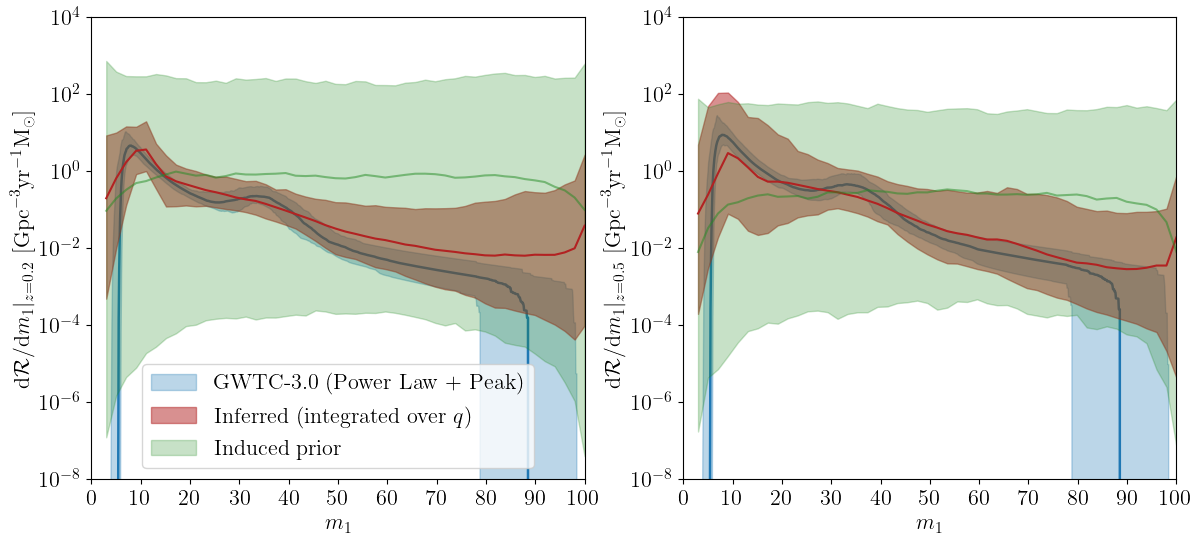

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

z_values_toplot = [0.2,1.0]
ymins = [1e-8, 1e-8]
ymaxs = [1e4, 1e4]

for n,zeval in enumerate([0.2,0.5]):
    ax = axes[n]
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    ax.plot(mass_1_gwtc3, np.median(dRdm1_gwtc3 *(1+zeval)**(kappas_gwtc3[inds,None]),axis=0),
        color=color_plpeak, lw=1.8, zorder=1,
       )
    ax.fill_between(mass_1_gwtc3,
        np.quantile(dRdm1_gwtc3 *(1+zeval)**(kappas_gwtc3[inds,None]),0.05,axis=0),
        np.quantile(dRdm1_gwtc3 *(1+zeval)**(kappas_gwtc3[inds,None]), 0.95, axis=0),
        color=color_plpeak, alpha=0.3,
        label='GWTC-3.0 (Power Law + Peak)',
        )
    
    dRdm1_zeval = np.sum(np.exp(square_rate[:,zeval_ind,:,:]) *to_comoving_volume[zeval_ind], axis=2) *dq
    low_dRdm1 = np.quantile(dRdm1_zeval, 0.05, axis=0)
    median_dRdm1 = np.quantile(dRdm1_zeval, 0.5, axis=0)
    high_dRdm1 = np.quantile(dRdm1_zeval, 0.95, axis=0)
    
    ax.plot(m1_grid, median_dRdm1, color="firebrick")
    ax.fill_between(m1_grid, low_dRdm1, high_dRdm1,
                    color="firebrick", alpha=0.5,
                    label=r'Inferred (integrated over $q$)',
                    )

    dRdm1_prior_zeval = np.sum(np.exp(square_rate_prior[:,zeval_ind,:,:]) 
                               *to_comoving_volume[zeval_ind], axis=2) *dq
    low_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.05, axis=0)
    median_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.5, axis=0)
    high_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.95, axis=0)
    ax.plot(m1_grid, median_dRdm1_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(m1_grid, low_dRdm1_prior, high_dRdm1_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$m_1$')
    ax.set_xlim(xmin=m1_min, xmax=m1_max)
    ax.set_xticks(np.linspace(0,m1_max,int(m1_max/10)+1))
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}\mathrm{M}_\odot]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

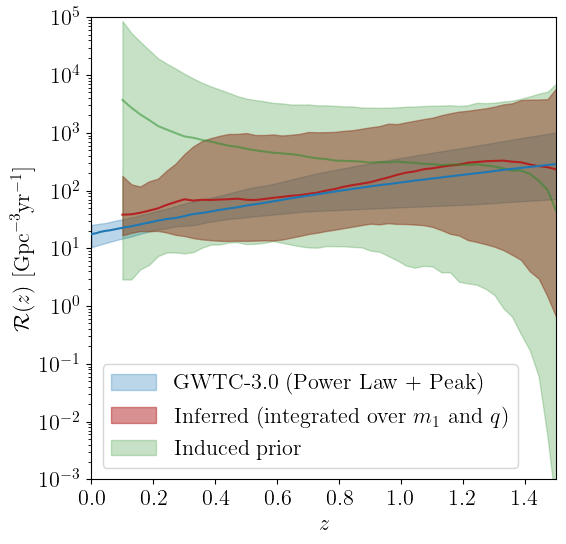

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.plot(zs_gwtc3, np.median(Rz_gwtc3,axis=0),
        color=color_plpeak, lw=1.5, zorder=5,
       )
ax.fill_between(zs_gwtc3,
        np.quantile(Rz_gwtc3,0.05,axis=0),
        np.quantile(Rz_gwtc3, 0.95, axis=0),
        color=color_plpeak, alpha=0.3,
        label='GWTC-3.0 (Power Law + Peak)',
        )

Rz = np.sum(np.exp(square_rate) 
              *to_comoving_volume[None,:,None,None], axis=(2,3)) *dq *dm1
low_Rz = np.quantile(Rz, 0.05, axis=0)
median_Rz = np.quantile(Rz, 0.5, axis=0)
high_Rz = np.quantile(Rz, 0.95, axis=0)

ax.plot(z_grid, median_Rz, color="firebrick")
ax.fill_between(z_grid, low_Rz, high_Rz,
                color="firebrick", alpha=0.5,
                label=r'Inferred (integrated over $m_1$ and $q$)',
                )

Rz_prior = np.sum(np.exp(square_rate_prior) 
                    *to_comoving_volume[None,:,None,None], axis=(2,3)) *dq *dm1
low_Rz_prior = np.quantile(Rz_prior, 0.05, axis=0)
median_Rz_prior = np.quantile(Rz_prior, 0.5, axis=0)
high_Rz_prior = np.quantile(Rz_prior, 0.95, axis=0)
ax.plot(z_grid, median_Rz_prior, color="forestgreen", alpha=0.5)
ax.fill_between(z_grid, low_Rz_prior, high_Rz_prior,
                color="forestgreen", alpha=0.25,
                label='Induced prior',
                )


ax.set_xlabel(r'$z$')
ax.set_xlim(xmin=z_min, xmax=z_max)
ax.set_xticks(np.linspace(0,z_max,int(z_max*10)+1)[::2])
ax.set_ylabel(r'$\mathcal{R}(z)\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.legend(loc='best')
#ax.set_box_aspect(1)
ax.set_ylim(ymin=1e-3, ymax=1e5)

plt.show()
plt.close()

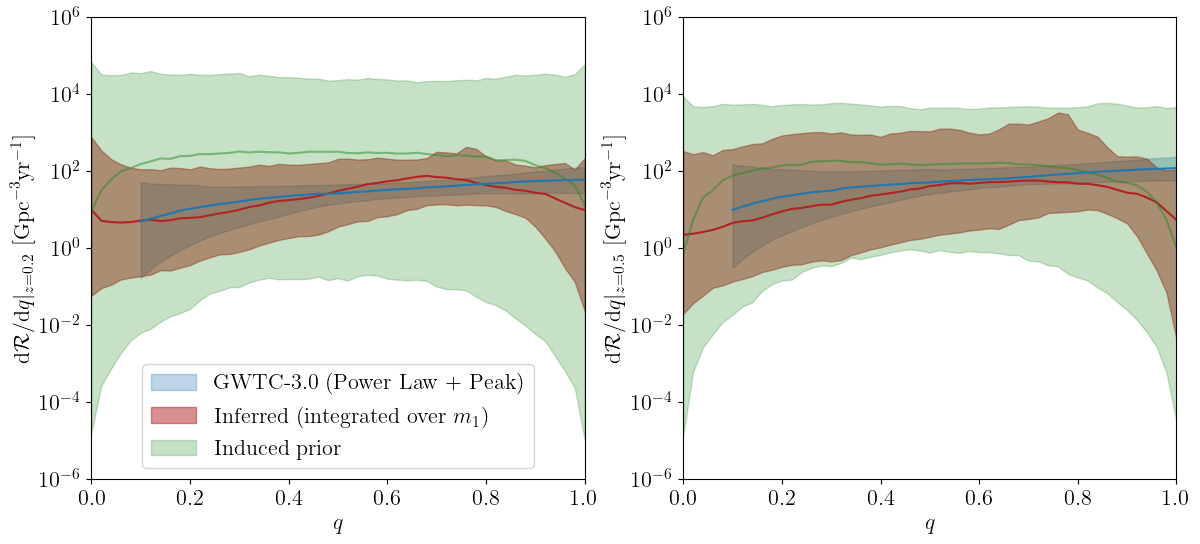

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

z_values_toplot = [0.2,1.0]
ymins = [1e-6, 1e-6]
ymaxs = [1e6, 1e6]

for n,zeval in enumerate([0.2,0.5]):
    ax = axes[n]
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    ax.plot(mass_ratio_gwtc3, np.median(dRdq_gwtc3 *(1+zeval)**(kappas_gwtc3[inds,None]),axis=0),
        color=color_plpeak, lw=1.5, zorder=5,
       )
    ax.fill_between(mass_ratio_gwtc3,
        np.quantile(dRdq_gwtc3 *(1+zeval)**(kappas_gwtc3[inds,None]),0.05,axis=0),
        np.quantile(dRdq_gwtc3 *(1+zeval)**(kappas_gwtc3[inds,None]), 0.95, axis=0),
        color=color_plpeak, alpha=0.3,
        label='GWTC-3.0 (Power Law + Peak)',
        )
    
    dRdq_zeval = np.sum(np.exp(square_rate[:,zeval_ind,:,:]) 
                        *to_comoving_volume[zeval_ind], axis=1) *dm1
    low_dRdq = np.quantile(dRdq_zeval, 0.05, axis=0)
    median_dRdq = np.quantile(dRdq_zeval, 0.5, axis=0)
    high_dRdq = np.quantile(dRdq_zeval, 0.95, axis=0)
    
    ax.plot(q_grid, median_dRdq, color="firebrick")
    ax.fill_between(q_grid, low_dRdq, high_dRdq,
                    color="firebrick", alpha=0.5,
                    label=r'Inferred (integrated over $m_1$)',
                    )
    
    dRdq_prior_zeval = np.sum(np.exp(square_rate_prior[:,zeval_ind,:,:]) 
                               *to_comoving_volume[zeval_ind], axis=1) *dm1
    low_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.05, axis=0)
    median_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.5, axis=0)
    high_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.95, axis=0)
    ax.plot(q_grid, median_dRdq_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(q_grid, low_dRdq_prior, high_dRdq_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$q$')
    ax.set_xlim(xmin=q_min, xmax=q_max)
    ax.set_xticks(np.linspace(0,1,6))
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

# 95% - 5% CI 

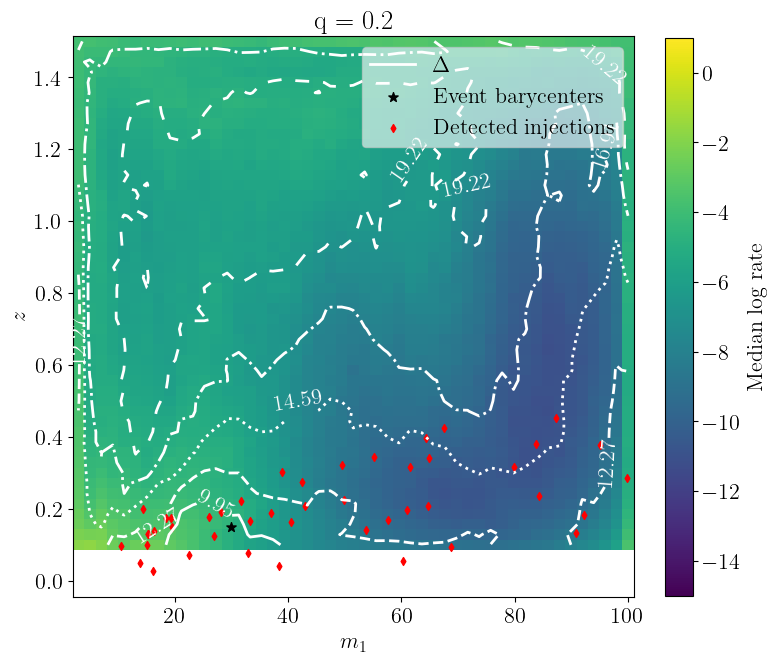

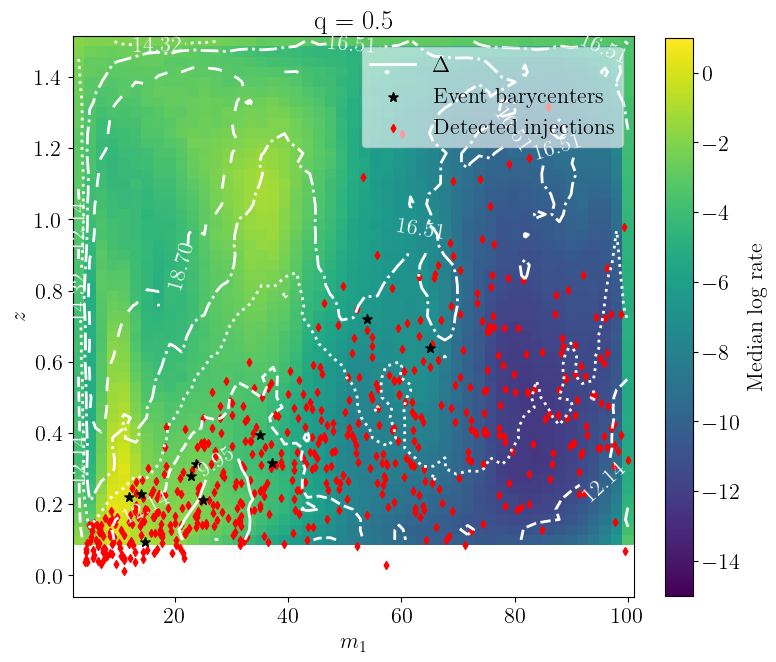

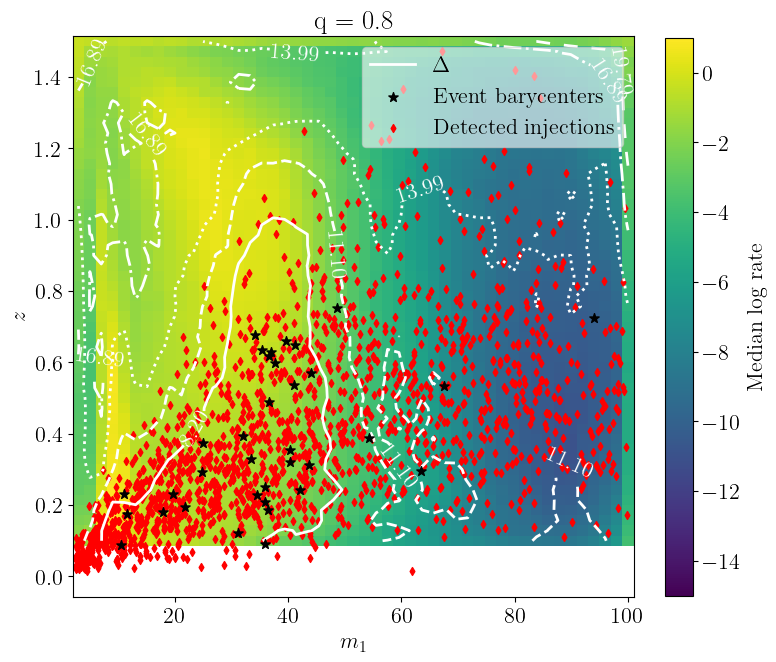

In [30]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for qeval in [0.2, 0.5, 0.8]:
    qeval_ind = np.argmin(np.abs(q_grid-qeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")


    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, qeval_ind] +np.log(to_comoving_volume[:,None]),
                      cmap=cmap, norm=norm,
                     )
    
    # Calculate the difference
    diff = high[:, :, qeval_ind] - low[:, :, qeval_ind]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, z_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[qeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_q = np.abs(detected_injections[:,2]-q_grid[qeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='upper right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

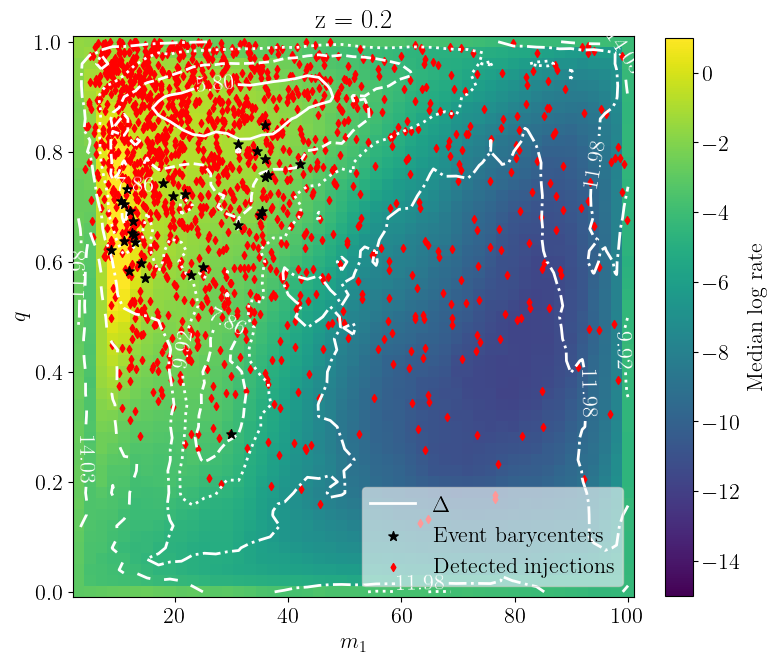

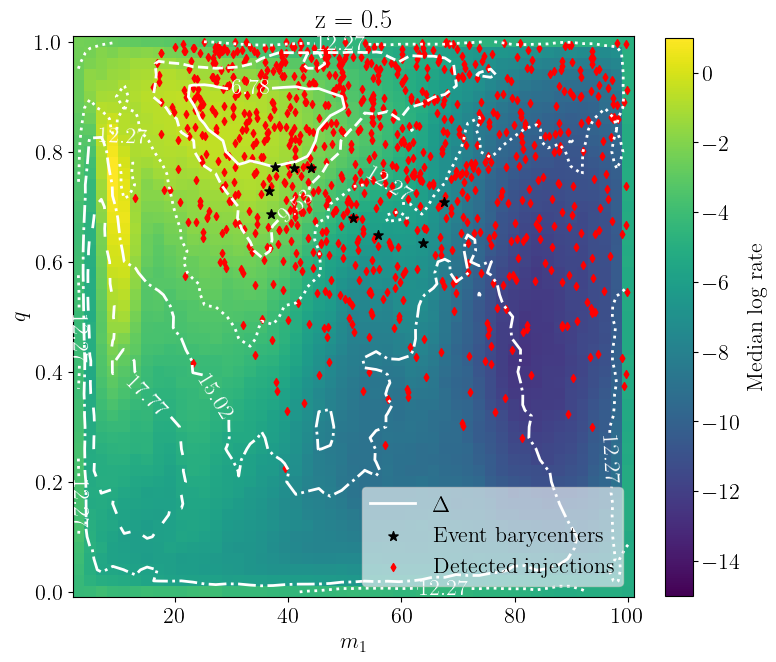

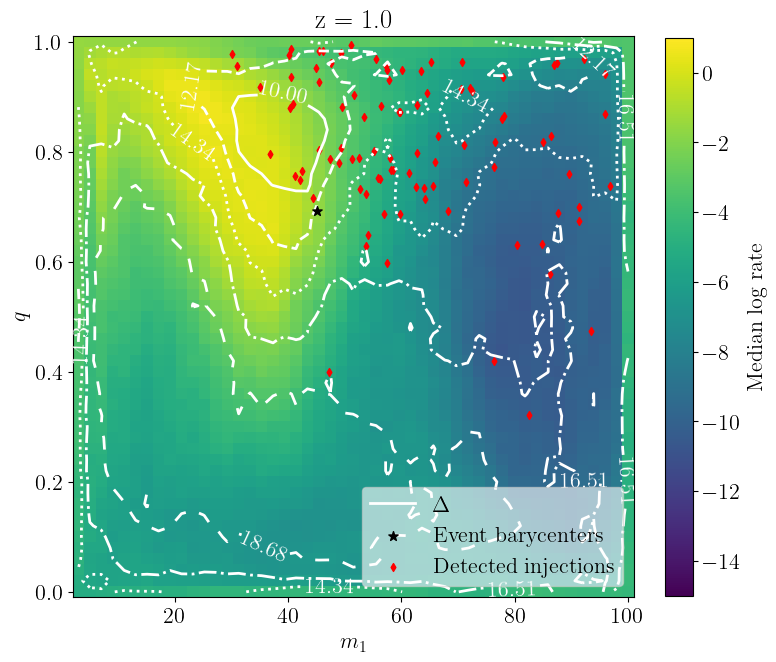

In [31]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for zeval in [0.2, 0.5, 1.0]:
    zeval_ind = np.argmin(np.abs(z_grid-zeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"z = {z_grid[zeval_ind]:.1f}")   
    
    c = ax.pcolormesh(m1_grid, q_grid, median[zeval_ind, :, :].T +np.log(to_comoving_volume[zeval_ind]),
                      cmap=cmap, norm=norm,
                     )

    
    # Calculate the difference
    diff = high[zeval_ind, :, :] - low[zeval_ind, :, :]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, q_grid, diff.T, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_z = np.abs(event_barycenters[:,1]-z_grid[zeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_z,0], event_barycenters[events_at_z,2],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_z = np.abs(detected_injections[:,1]-z_grid[zeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_z,0], detected_injections[injections_at_z,2],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$q$')
    ax.legend(loc='lower right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

# Delta

In [32]:
diff = high-low
interp_delta = RegularGridInterpolator((z_grid, m1_grid, q_grid), diff, bounds_error=False, fill_value=np.nan)

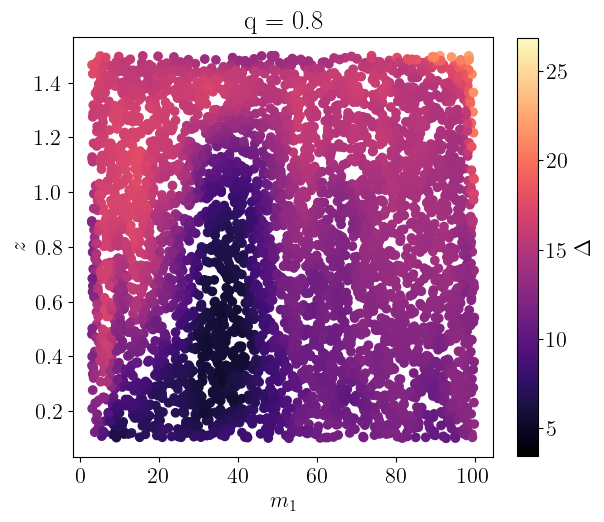

In [33]:
qeval = 0.8
qeval_ind = np.argmin(np.abs(q_grid-qeval))

cmap=plt.get_cmap('magma')
norm=mpl.colors.Normalize(vmin=np.min(diff), vmax=np.max(diff))
fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=qeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],
              c=interp_delta(samples_try[:,(1,0,2)]),
              cmap=cmap, norm=norm,
             )
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'$\Delta$')

plt.show()
plt.close()

In [34]:
delta_levels = np.linspace(np.min(diff), np.max(diff), 20)[1:-1]
print(delta_levels)

[ 4.68043905  5.91257141  7.14470377  8.37683613  9.60896849 10.84110085
 12.07323321 13.30536557 14.53749793 15.76963029 17.00176265 18.23389501
 19.46602737 20.69815973 21.93029209 23.16242445 24.39455681 25.62668917]


In [35]:
samples_per_tri = 1_000
ndraw = 10_000

ints_delta={}
ints_delta_LVK={}
volume = np.prod(corners.max(axis=0) - corners.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for delta in delta_levels:
    print(delta)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))
    cosmo_fac=np.zeros(ndraw)

    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep       
        inds_proposal_keep=np.argwhere(interp_delta(new_points[:,(1,0,2)])<delta)[:,0]
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])
        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_delta[delta]=np.zeros(num_triangulations)
    ints_delta_LVK[delta]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)
        ints_delta[delta][ind] = mean_fx * frac_kept * volume
        
    for ind in tqdm(range(num_pop_LVK)):
        pdf_m1 = interp1d(x=mass_1_gwtc3, 
                          y=dRdm1_gwtc3[ind] /Rz_gwtc3[ind,0], 
                          fill_value="extrapolate")
        rate_z = interp1d(x=zs_gwtc3, 
                          y=Rz_gwtc3[ind], 
                          fill_value="extrapolate")
        pdf_q = interp1d(x=mass_ratio_gwtc3, 
                         y=dRdq_gwtc3[ind] /Rz_gwtc3[ind,0], 
                         fill_value="extrapolate")
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
            *pdf_q(proposals[:,2])
        ).mean()       
        ints_delta_LVK[delta][ind] = mean_Nx * frac_kept * volume

4.680439052560429


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 418.87it/s]


5.912571412436796


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 369.91it/s]


7.144703772313163


...

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 314.39it/s]


24.3945568105823


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 375.90it/s]


25.62668917045867


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 343.81it/s]


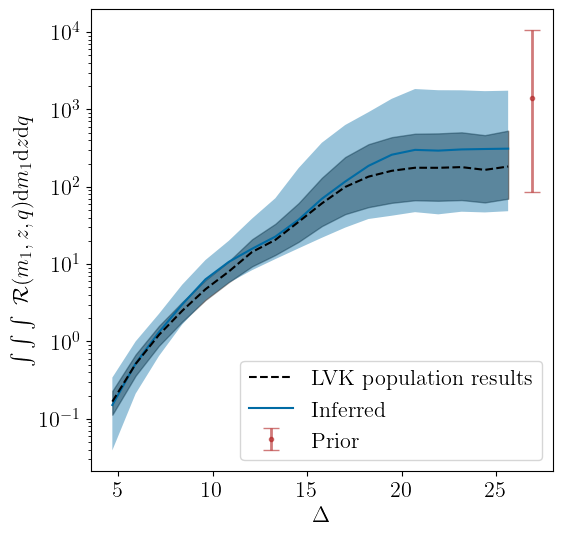

In [36]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_delta_LVK[delta]) for delta in delta_levels]
low_LVK = [ np.quantile(ints_delta_LVK[delta], 0.05) for delta in delta_levels]
high_LVK = [ np.quantile(ints_delta_LVK[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(delta_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_delta = [ np.median(ints_delta[delta]) for delta in delta_levels]
low_delta = [ np.quantile(ints_delta[delta], 0.05) for delta in delta_levels]
high_delta = [ np.quantile(ints_delta[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_delta, label='Inferred')
ax.fill_between(delta_levels, low_delta, high_delta, alpha=0.4)

ax.errorbar(delta_levels[-1]*1.05, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower right')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()

# KL divergences

In [37]:
m1_grid_coarse = np.linspace(m1_min, m1_max, 19)
z_grid_coarse = np.linspace(0.1, z_max, 20)
q_grid_coarse = np.linspace(q_min, q_max, 21)

X_coarse, Y_coarse, Z_coarse = np.meshgrid(m1_grid_coarse, z_grid_coarse, q_grid_coarse)
grid_coarse = np.c_[X_coarse.ravel(), Y_coarse.ravel(), Z_coarse.ravel()]

dm1_coarse = m1_grid_coarse[1] - m1_grid_coarse[0]
dz_coarse = z_grid_coarse[1] - z_grid_coarse[0]
dq_coarse = q_grid_coarse[1] - q_grid_coarse[0]

to_comoving_volume_coarse = (1 + z_grid_coarse) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid_coarse).to(u.Gpc**3 / u.sr).value
    )

In [38]:
log_rate_coarse = np.zeros((num_triangulations, grid_coarse.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_coarse[ind] = this_delo.interpolate(grid_coarse)
    
square_rate_coarse = log_rate_coarse.reshape(num_triangulations, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0])

100%|█████████████████████████████████████| 1000/1000 [00:02<00:00, 345.18it/s]


In [39]:
nsamples_prior = 1_000
log_rate_prior_coarse = np.zeros((nsamples_prior, grid_coarse.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+offset,ndim+1))
    tri_i[:offset,:-1] = corners
    tri_i[offset:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[offset:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[offset:,2] = np.random.uniform(q_min, q_max, nleaves_i)
    tri_i[:,-1] = np.random.uniform(w_min, w_max, nleaves_i+offset)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior_coarse[i] = this_delo.interpolate(grid_coarse)

square_rate_prior_coarse = log_rate_prior_coarse.reshape(nsamples_prior, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0])

100%|█████████████████████████████████████| 1000/1000 [00:03<00:00, 278.28it/s]


In [40]:
kl_divs=np.zeros((len(z_grid_coarse),len(m1_grid_coarse),len(q_grid_coarse)))

for i,j,k in product(range(z_grid_coarse.shape[0]),range(m1_grid_coarse.shape[0]),range(q_grid_coarse.shape[0])):
    kl_divs[i,j,k] = kl_divergence_kde(square_rate_coarse[:,i,j,k],square_rate_prior_coarse[:,i,j,k])

In [41]:
interp_kl = RegularGridInterpolator((z_grid_coarse, m1_grid_coarse, q_grid_coarse), kl_divs, bounds_error=False, fill_value=np.nan)

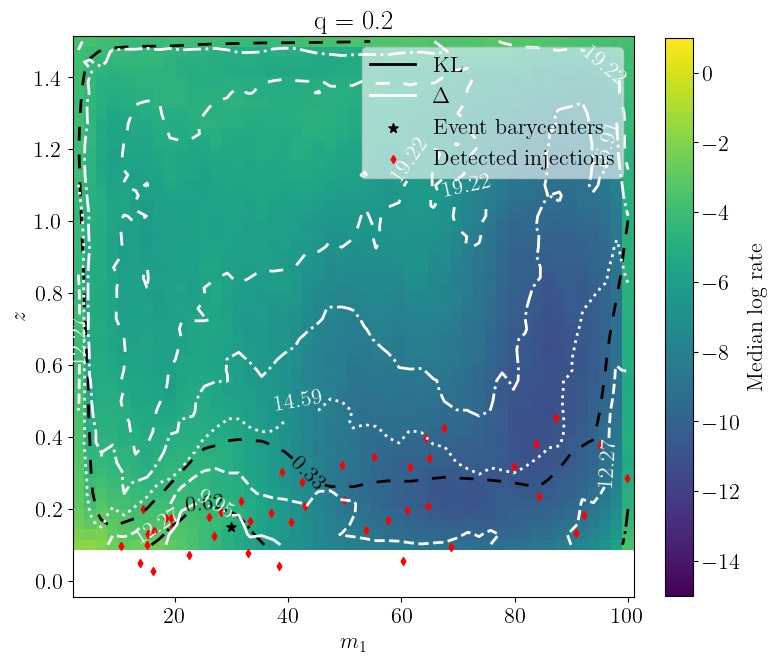

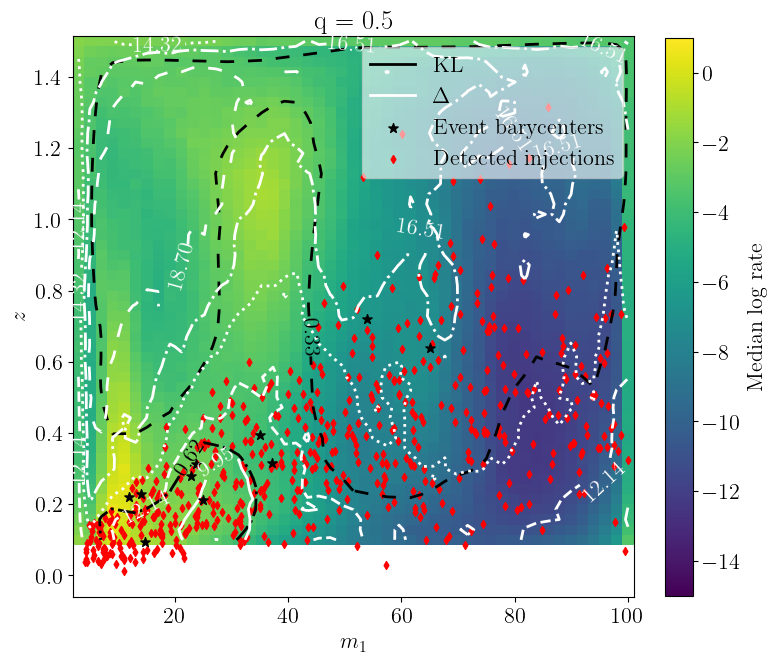

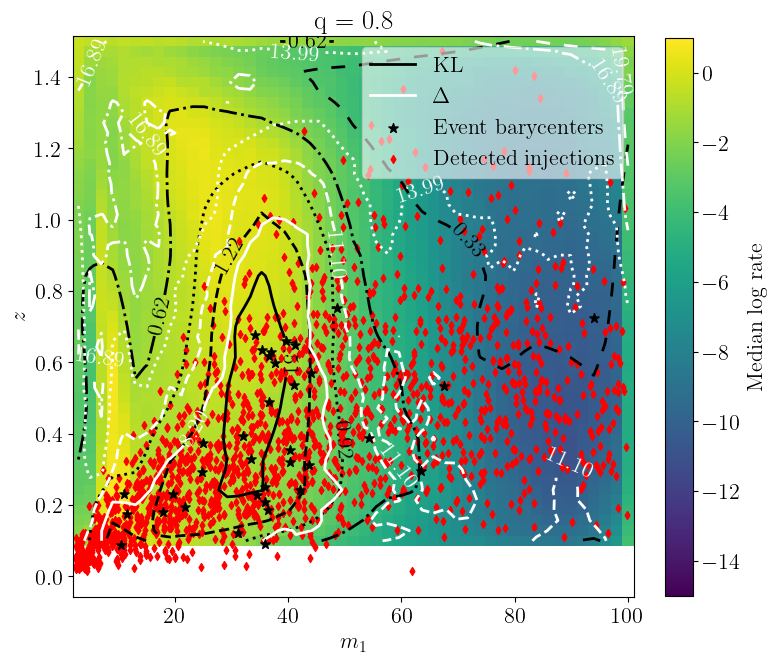

In [42]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for qeval in [0.2, 0.5, 0.8]:
    qeval_ind = np.argmin(np.abs(q_grid-qeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, qeval_ind] +np.log(to_comoving_volume[:,None]),
                      cmap=cmap, norm=norm,
                     )

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    Xz0, Yz0, Zz0 = np.meshgrid(m1_grid, z_grid, np.array([q_grid[qeval_ind]]))
    # grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]
    grid_z0 = np.c_[Yz0.ravel(), Xz0.ravel(), Zz0.ravel()]

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        m1_grid, z_grid, interp_kl(grid_z0).reshape(len(z_grid),len(m1_grid)), 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours][::-1],
        linewidths=2, 
        colors='black'
    )
    ax.clabel(contours_kl, fmt="%.2f")
    ax.plot([],[], lw=2, color='k', label='KL')

    ## Overplot contours of diff log-rate ## 35
    # Calculate the difference
    diff = high[:, :, qeval_ind] - low[:, :, qeval_ind]
    # Define contour levels (choose appropriate values for your data)
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max
    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, z_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[qeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_q = np.abs(detected_injections[:,2]-q_grid[qeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='upper right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

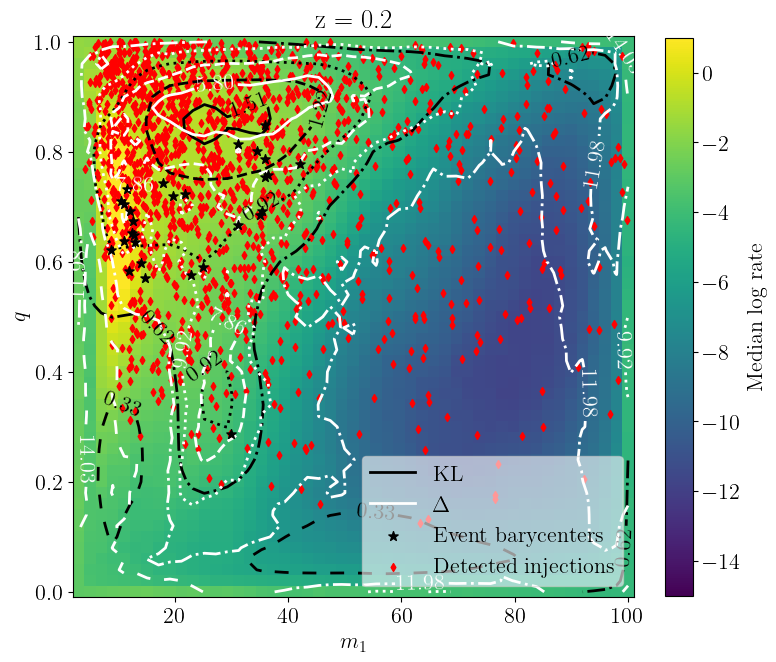

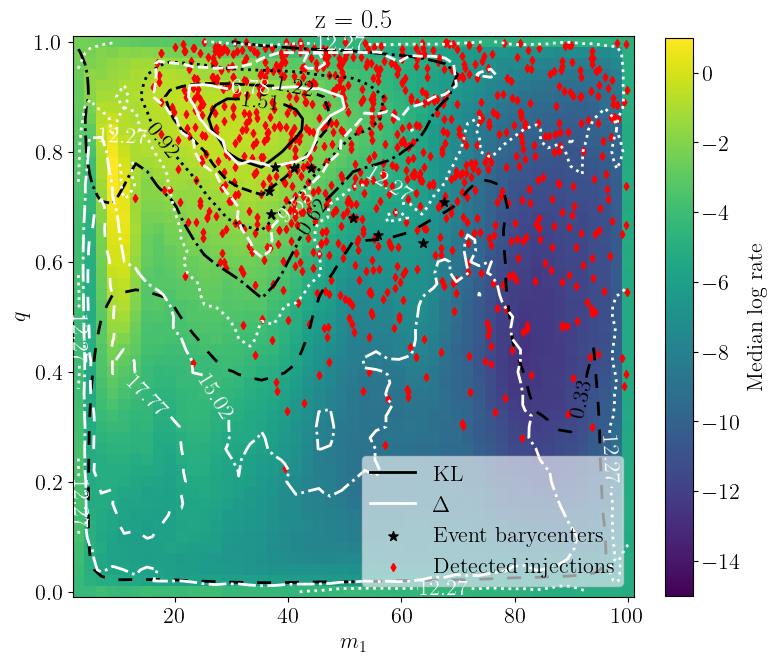

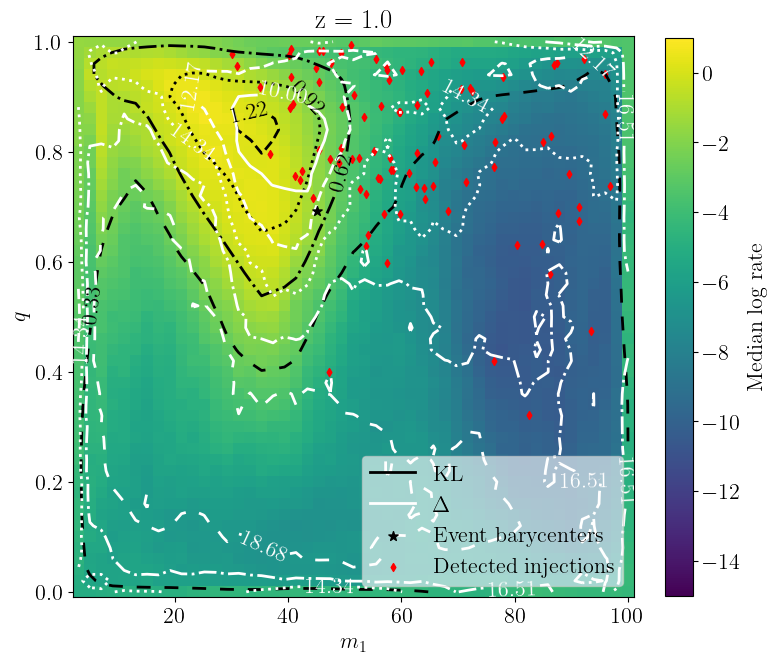

In [43]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for zeval in [0.2, 0.5, 1.0]:
    zeval_ind = np.argmin(np.abs(z_grid-zeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"z = {z_grid[zeval_ind]:.1f}")   
    
    c = ax.pcolormesh(m1_grid, q_grid, median[zeval_ind, :, :].T +np.log(to_comoving_volume[zeval_ind]),
                      cmap=cmap, norm=norm,
                     )

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    Xz0, Yz0, Zz0 = np.meshgrid(m1_grid, np.array([z_grid[zeval_ind]]), q_grid)
    # grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]
    grid_z0 = np.c_[Yz0.ravel(), Xz0.ravel(), Zz0.ravel()]

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        m1_grid, q_grid, interp_kl(grid_z0).reshape(len(m1_grid),len(q_grid)).T, 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours][::-1],
        linewidths=2, 
        colors='black'
    )
    ax.clabel(contours_kl, fmt="%.2f")
    ax.plot([],[], lw=2, color='k', label='KL')

    
    # Calculate the difference
    diff = high[zeval_ind, :, :] - low[zeval_ind, :, :]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, q_grid, diff.T, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_z = np.abs(event_barycenters[:,1]-z_grid[zeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_z,0], event_barycenters[events_at_z,2],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_z = np.abs(detected_injections[:,1]-z_grid[zeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_z,0], detected_injections[injections_at_z,2],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$q$')
    ax.legend(loc='lower right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

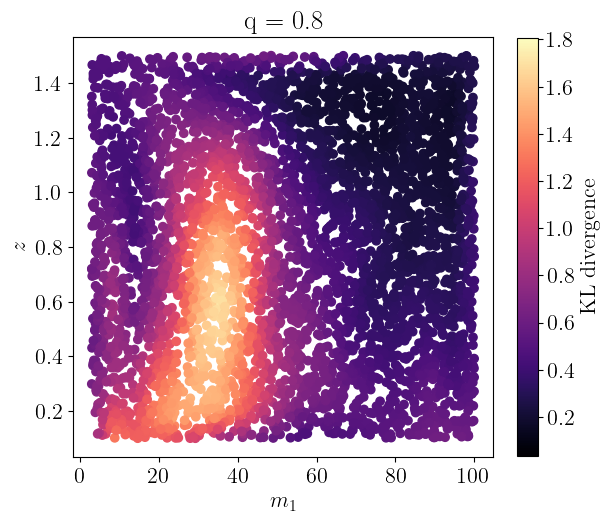

In [44]:
qeval = 0.8
qeval_ind = np.argmin(np.abs(q_grid-qeval))

cmap=plt.get_cmap('magma')
norm=mpl.colors.Normalize(vmin=np.min(kl_divs), vmax=np.max(kl_divs))
fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=qeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],
              c=interp_kl(samples_try[:,(1,0,2)]),
              cmap=cmap, norm=norm,
             )
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'KL divergence')

plt.show()
plt.close()

In [45]:
kl_levels = np.linspace(0, np.max(kl_divs), 20)[1:-1]
print(kl_levels)

[0.09511251 0.19022502 0.28533752 0.38045003 0.47556254 0.57067505
 0.66578755 0.76090006 0.85601257 0.95112508 1.04623758 1.14135009
 1.2364626  1.33157511 1.42668761 1.52180012 1.61691263 1.71202514]


In [46]:
samples_per_tri = 1_000
ndraw = 10_000

ints_kl={}
ints_kl_LVK={}
volume = np.prod(corners.max(axis=0) - corners.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for kl in np.flip(kl_levels):
    print(kl)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))
    cosmo_fac=np.zeros(ndraw)
    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points[:,(1,0,2)])>kl)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])

        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_kl[kl]=np.zeros(num_triangulations)
    ints_kl_LVK[kl]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)        
        ints_kl[kl][ind]= mean_fx * frac_kept * volume

    for ind in tqdm(range(num_pop_LVK)):
        pdf_m1 = interp1d(x=mass_1_gwtc3, 
                          y=dRdm1_gwtc3[ind] /Rz_gwtc3[ind,0], 
                          fill_value="extrapolate")
        rate_z = interp1d(x=zs_gwtc3, 
                          y=Rz_gwtc3[ind], 
                          fill_value="extrapolate")
        pdf_q = interp1d(x=mass_ratio_gwtc3, 
                         y=dRdq_gwtc3[ind] /Rz_gwtc3[ind,0], 
                         fill_value="extrapolate")
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
            *pdf_q(proposals[:,2])
        ).mean()       
        ints_kl_LVK[kl][ind] = mean_Nx * frac_kept * volume

1.7120251368306425


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 478.41it/s]


1.6169126292289402


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 454.42it/s]


1.5218001216272379


...

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 350.58it/s]


0.19022501520340473


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 339.93it/s]


0.09511250760170237


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 366.70it/s]


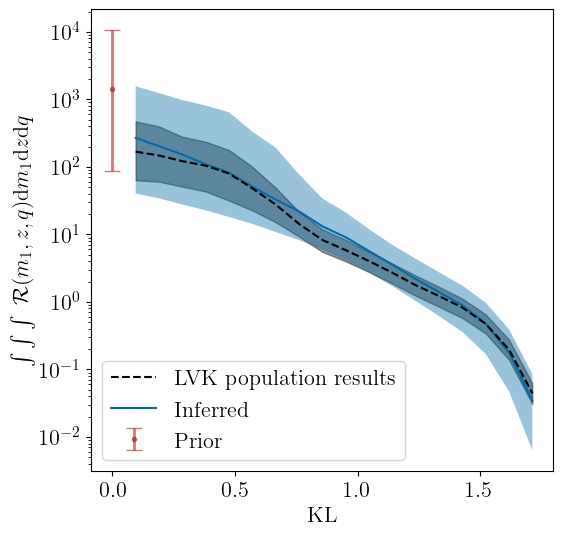

In [47]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_kl_LVK[delta]) for delta in kl_levels]
low_LVK = [ np.quantile(ints_kl_LVK[delta], 0.05) for delta in kl_levels]
high_LVK = [ np.quantile(ints_kl_LVK[delta], 0.95) for delta in kl_levels]

ax.plot(kl_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(kl_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_kl = [ np.median(ints_kl[kl]) for kl  in kl_levels]
low_kl = [ np.quantile(ints_kl[kl], 0.05) for kl  in kl_levels]
high_kl = [ np.quantile(ints_kl[kl], 0.95) for kl  in kl_levels]

ax.plot(kl_levels, median_kl, label='Inferred')
ax.fill_between(kl_levels, low_kl, high_kl, alpha=0.4)

ax.errorbar(0, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

ax.set_xlabel(r'KL')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower left')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()